# Predikcija broja kupnji korisnika

**Kolegij:** Uvod u podatkovnu znanost
**Autori:** Iva Lucija Borovac, Tea Leko, Karla Sušac

**Skup podataka:** E-Commerce Behavior Data from Multi Category Store (Kaggle, mkechinov)
https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store

---

**Napomena o podatkovnom skupu:** originalni Kaggle skup sadrži preko 100 milijuna
zapisa (events) i nekoliko GB podataka, što ga čini nepraktičnim za rad na običnom
računalu u sklopu jednog projekta. Zbog toga je u ovom projektu korišten **sintetički
generiran skup podataka iste strukture** (iste kolone: `event_time`, `event_type`,
`product_id`, `category_code`, `brand`, `price`, `user_id`, `user_session`) i sličnih
statističkih svojstava (omjer view/cart/purchase eventova, raspodjela cijena po
kategorijama, broj korisnika i sesija). Skup je generiran skriptom
`generate_raw_data.py` koja je priložena uz ovaj notebook, te namjerno sadrži
nedostajuće vrijednosti, duplikate i outliere - baš kao i stvarni "sirovi" podaci -
kako bi se mogao demonstrirati cijeli proces čišćenja i pripreme podataka.


## 1. Uvod

**Problem koji se rješava:** U online trgovinama vrlo je vrijedno znati koji
korisnici imaju veću vjerojatnost da će izvršiti kupnju (ili više kupnji) na temelju
njihova ponašanja na stranici (broj pregleda proizvoda, broj sesija, kategorije koje
ih interesiraju, cijene proizvoda koje gledaju, itd.). U ovom projektu rješava se
**regresijski problem predikcije broja kupnji korisnika** na temelju podataka o
njegovom ponašanju (events log) u e-trgovini.

**Zašto je problem relevantan:** Predikcija broja kupnji korisniku omogućuje
e-trgovinama da:
- prepoznaju korisnike s visokim potencijalom kupnje (npr. za ciljani marketing),
- personaliziraju preporuke i popuste,
- procijene buduće prihode na temelju ponašanja korisnika,
- identificiraju korisnike kojima treba dodatni "poticaj" (npr. remarketing) jer
  pokazuju interes (cart) ali ne kupuju.

**Cilj projekta:** Izgraditi i evaluirati regresijski model koji na temelju
agregiranih značajki ponašanja korisnika (broj pregleda, broj sesija, broj
kategorija/brandova koje je pregledao, prosječna i maksimalna cijena pregledanih
proizvoda i sl.) predviđa **broj kupnji** koje će korisnik izvršiti u promatranom
razdoblju. Usput se demonstrira cijeli tipičan tijek rada u podatkovnoj znanosti:
čišćenje podataka, deskriptivna analiza, feature engineering, treniranje više
regresijskih modela te njihova evaluacija i usporedba.


## 2. Opis i analiza skupa podataka

### 2.1 Izvor i kontekst skupa podataka

Skup podataka simulira strukturu javno dostupnog Kaggle skupa **"eCommerce behavior
data from multi category store"** (autor: mkechinov,
https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store).
Izvorni skup objavljen je od strane tvrtke Open CDP (Customer Data Platform) i sadrži
zapise ponašanja korisnika (events) prikupljene na stranici multikategorijske online
trgovine tijekom nekoliko mjeseci. Područje primjene je **e-trgovina / digitalni
marketing**, a svrha skupa podataka je analiza ponašanja korisnika (pregledavanje,
dodavanje u košaricu, kupnja) radi boljeg razumijevanja korisničkog puta (customer
journey) i izgradnje prediktivnih modela.

Zbog svoje veličine (>100 milijuna redaka u originalu), za potrebe ovog projekta
generiran je sintetički skup s istom shemom podataka i sličnim statističkim
svojstvima (vidi napomenu na početku notebooka).

### 2.2 Struktura podataka

Sirovi (raw) skup podataka sadrži jedan zapis (red) po svakom događaju (eventu) koji
je korisnik izveo na stranici. Kolone:

| Kolona | Opis | Tip |
|---|---|---|
| `event_time` | vrijeme događaja | datetime |
| `event_type` | tip događaja: `view`, `cart`, `purchase` | kategorijska |
| `product_id` | ID proizvoda | numerička (ID) |
| `category_code` | kategorija proizvoda | kategorijska |
| `brand` | brand/marka proizvoda | kategorijska |
| `price` | cijena proizvoda | numerička |
| `user_id` | ID korisnika | numerička (ID) |
| `user_session` | ID sesije korisnika | kategorijska |

Ispod slijedi učitavanje skupa i pregled njegove strukture.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Učitavanje sirovog (raw) skupa podataka
df = pd.read_csv("data/ecommerce_events_raw.csv", parse_dates=["event_time"])

print("Dimenzije skupa (broj redaka, broj stupaca):", df.shape)
df.head()


Dimenzije skupa (broj redaka, broj stupaca): (78068, 8)


,event_time,event_type,product_id,category_code,brand,price,user_id,user_session
0,2023-02-22 20:07:05,view,3670280,construction.tools.light,xiaomi,41.83,776149,s776149_0
1,2023-01-15 20:22:32,view,2468841,accessories.bag,xiaomi,22.31,775373,s775373_2
2,2023-02-02 04:22:26,cart,6672741,kids.toys,logitech,NaN,501465,s501465_0
3,2023-01-19 01:19:25,cart,6831333,construction.tools.light,huawei,39.20,816453,s816453_19
4,2023-03-22 00:14:19,view,9406307,computers.notebook,ikea,774.61,580222,s580222_2


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78068 entries, 0 to 78067
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_time     78068 non-null  datetime64[ns]
 1   event_type     78068 non-null  object        
 2   product_id     78068 non-null  int64         
 3   category_code  75688 non-null  object        
 4   brand          71484 non-null  object        
 5   price          77284 non-null  float64       
 6   user_id        78068 non-null  int64         
 7   user_session   78068 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 4.8+ MB


In [3]:
# Broj jedinstvenih korisnika, proizvoda i sesija
print("Broj jedinstvenih korisnika:", df["user_id"].nunique())
print("Broj jedinstvenih proizvoda:", df["product_id"].nunique())
print("Broj jedinstvenih sesija:", df["user_session"].nunique())
print("\nBroj zapisa po tipu eventa:")
print(df["event_type"].value_counts())


Broj jedinstvenih korisnika: 3988
Broj jedinstvenih proizvoda: 76216
Broj jedinstvenih sesija: 21936

Broj zapisa po tipu eventa:
event_type
view        57404
purchase    10367
cart        10297
Name: count, dtype: int64


**Nedostajuće vrijednosti:** u sirovom skupu postoje nedostajuće vrijednosti u
kolonama `category_code`, `brand` i `price` (slično kao u stvarnom Kaggle skupu, gdje
velik dio proizvoda nema upisanu kategoriju ili brand).


In [4]:
# Provjera nedostajućih vrijednosti
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"broj_null": missing, "postotak_null": missing_pct})


,broj_null,postotak_null
event_time,0,0.00
event_type,0,0.00
product_id,0,0.00
category_code,2380,3.05
brand,6584,8.43
price,784,1.00
user_id,0,0.00
user_session,0,0.00


**Duplikati:** provjeravamo postoje li potpuno identični (duplicirani) redovi u
skupu, što se može dogoditi npr. zbog greške u logiranju eventova.


In [5]:
broj_duplikata = df.duplicated().sum()
print(f"Broj potpuno dupliciranih redaka: {broj_duplikata} "
      f"({broj_duplikata / len(df) * 100:.2f}% skupa)")


Broj potpuno dupliciranih redaka: 1528 (1.96% skupa)


### 2.3 Ciljna varijabla

Cilj ovog projekta nije predviđanje pojedinačnog eventa, već **broja kupnji po
korisniku** u promatranom razdoblju. Zato je potrebno sirove podatke (po eventu)
agregirati na razinu korisnika - to je objašnjeno u poglavlju 2.4 (Pretprocesiranje),
a ciljna varijabla `n_purchases` definirana je kao:

> **n_purchases** = broj zapisa s `event_type == "purchase"` za danog korisnika u
> promatranom razdoblju.

Radi se o **brojevnoj (count) varijabli** s vrijednostima 0, 1, 2, 3... Raspon
vrijednosti i distribucija prikazani su u nastavku (nakon agregacije podataka).

### 2.4 Pretprocesiranje i priprema podataka

Koraci čišćenja i pripreme podataka:

1. **Uklanjanje dupliciranih redaka** - identični redovi su pogreška u logiranju i
   brišu se.
2. **Obrada nedostajućih vrijednosti** - `category_code` i `brand` popunjavaju se
   vrijednošću `"unknown"` (jer je nedostatak kategorije/brand-a informativan podatak
   sam po sebi, ne smije se brisati red), a `price` se popunjava medijanom cijene
   (robusno na outliere).
3. **Detekcija i obrada outliera** - na koloni `price` koristi se **IQR metoda**:
   redovi s cijenom izvan raspona [Q1 - 1.5·IQR, Q3 + 1.5·IQR] smatraju se outlierima
   i uklanjaju se (vjerojatno greška u unosu cijene).
4. **Agregacija na razinu korisnika i feature engineering** - sirovi event-log
   pretvara se u jedan red po korisniku s izvedenim značajkama (broj pregleda, broj
   sesija, broj kategorija, prosječna cijena i sl.) - detaljno opisano u poglavlju 3.


In [6]:
# 1) Uklanjanje dupliciranih redaka
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Prije uklanjanja duplikata: {df.shape[0]} redaka")
print(f"Nakon uklanjanja duplikata: {df_clean.shape[0]} redaka")


Prije uklanjanja duplikata: 78068 redaka
Nakon uklanjanja duplikata: 76540 redaka



Nakon uklanjanja duplikata: 76540 redaka


In [7]:
# 2) Obrada nedostajućih vrijednosti
df_clean["category_code"] = df_clean["category_code"].fillna("unknown")
df_clean["brand"] = df_clean["brand"].fillna("unknown")
df_clean["price"] = df_clean["price"].fillna(df_clean["price"].median())

print("Null vrijednosti nakon obrade:")
print(df_clean.isnull().sum())


Null vrijednosti nakon obrade:
event_time       0
event_type       0
product_id       0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64


Q1=36.09, Q3=399.88, IQR=363.79
Donja granica: -509.60, gornja granica: 945.57
Broj outliera u cijeni: 853 (1.11% skupa)


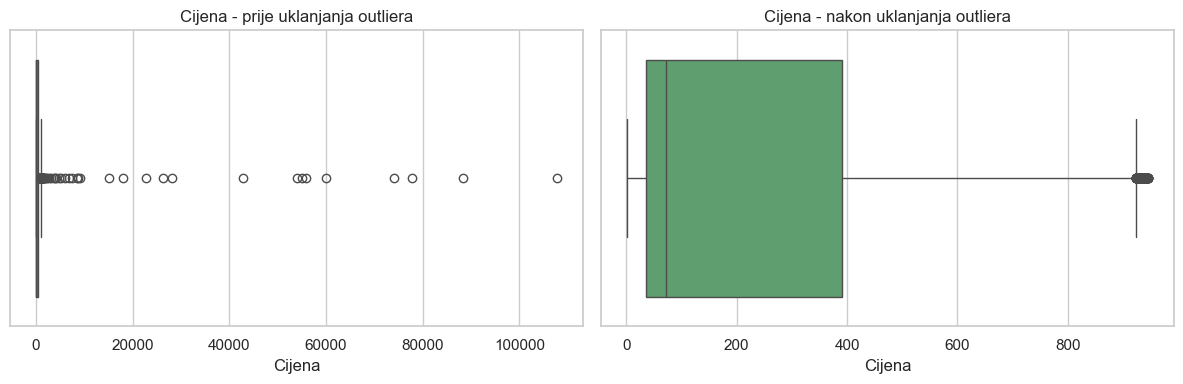


Dimenzije skupa nakon čišćenja: (75687, 8)


In [8]:
# 3) Detekcija i uklanjanje outliera u cijeni (IQR metoda)
Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Donja granica: {lower_bound:.2f}, gornja granica: {upper_bound:.2f}")

n_outliers = ((df_clean["price"] < lower_bound) | (df_clean["price"] > upper_bound)).sum()
print(f"Broj outliera u cijeni: {n_outliers} ({n_outliers/len(df_clean)*100:.2f}% skupa)")

# Vizualizacija prije uklanjanja outliera
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_clean["price"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Cijena - prije uklanjanja outliera")
axes[0].set_xlabel("Cijena")

df_clean = df_clean[(df_clean["price"] >= lower_bound) & (df_clean["price"] <= upper_bound)].reset_index(drop=True)

sns.boxplot(x=df_clean["price"], ax=axes[1], color="#55A868")
axes[1].set_title("Cijena - nakon uklanjanja outliera")
axes[1].set_xlabel("Cijena")
plt.tight_layout()
plt.show()

print(f"\nDimenzije skupa nakon čišćenja: {df_clean.shape}")


### Deskriptivna statistika (nakon čišćenja, na razini eventova)

In [9]:
df_clean[["price"]].describe()


,price
count,75687.000000
mean,216.194087
std,237.284129
min,1.000000
25%,35.760000
50%,71.090000
75%,390.740000
max,945.250000


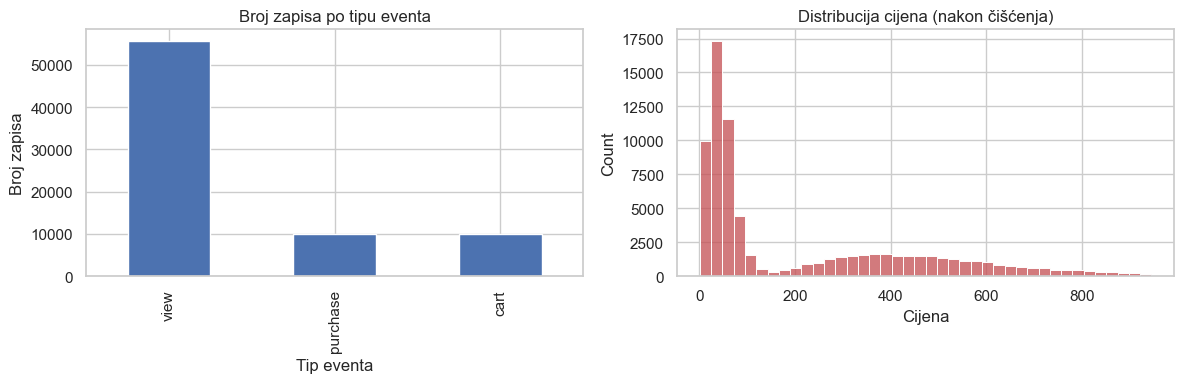

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clean["event_type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Broj zapisa po tipu eventa")
axes[0].set_xlabel("Tip eventa")
axes[0].set_ylabel("Broj zapisa")

sns.histplot(df_clean["price"], bins=40, ax=axes[1], color="#C44E52")
axes[1].set_title("Distribucija cijena (nakon čišćenja)")
axes[1].set_xlabel("Cijena")

plt.tight_layout()
plt.show()


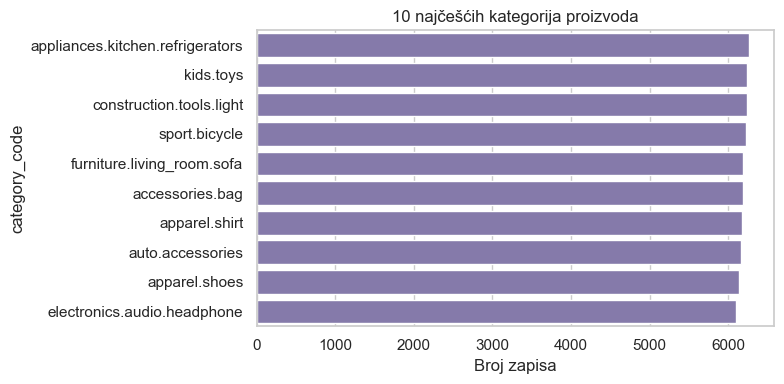

In [11]:
top_categories = df_clean["category_code"].value_counts().head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top_categories.values, y=top_categories.index, color="#8172B2")
plt.title("10 najčešćih kategorija proizvoda")
plt.xlabel("Broj zapisa")
plt.tight_layout()
plt.show()


## 3. Modeliranje problema

### Agregacija podataka na razinu korisnika (feature engineering)

Sirovi skup podataka sadrži jedan red po **eventu**, a nama je potreban jedan red po
**korisniku** (jer želimo predvidjeti broj kupnji *korisnika*, ne pojedinog eventa).
Zato se podaci agregiraju po `user_id`, a za svakog korisnika izvodimo skup značajki
koje opisuju njegovo ponašanje **prije/tijekom** kupovanja:

- `n_views` - broj pregleda proizvoda (view eventi)
- `n_sessions` - broj jedinstvenih sesija korisnika
- `n_categories` - broj različitih kategorija proizvoda koje je korisnik pregledao
- `n_brands` - broj različitih brandova koje je korisnik pregledao
- `avg_price` - prosječna cijena proizvoda koje je korisnik pregledao/dirao
- `max_price` - najveća cijena proizvoda koje je pregledao
- `total_price_viewed` - ukupna (zbrojena) cijena svih proizvoda koje je pregledao
- `events_per_session` - prosječan broj eventova po sesiji (mjera angažiranosti)

**Napomena o izboru značajki:** namjerno **nismo** koristili broj `cart` eventova ni
ukupan broj svih eventova kao značajke, jer su ti brojevi u ovom (sintetičkom) skupu
generirani zajedno s brojem kupnji pa bi njihovo korištenje dovelo do **curenja
podataka (data leakage)** - model bi "vidio" gotovo izravnu informaciju o cilju i
rezultati bi bili neumjereno dobri/nerealni. Korištene su samo značajke vezane za
**pregledavanje (view)** proizvoda, koje opisuju interes i ponašanje korisnika prije
kupnje, bez izravne informacije o samom broju kupnji.

Ciljna varijabla je `n_purchases` - broj `purchase` eventova po korisniku.


In [12]:
# Agregacija na razinu korisnika
user_df = df_clean.groupby("user_id").agg(
    n_views=("event_type", lambda x: (x == "view").sum()),
    n_sessions=("user_session", "nunique"),
    n_categories=("category_code", "nunique"),
    n_brands=("brand", "nunique"),
    avg_price=("price", "mean"),
    max_price=("price", "max"),
    total_price_viewed=("price", "sum"),
    n_purchases=("event_type", lambda x: (x == "purchase").sum()),
).reset_index()

user_df["events_per_session"] = user_df["n_views"] / user_df["n_sessions"]
user_df = user_df.fillna(0)

print("Dimenzije agregiranog skupa (jedan red po korisniku):", user_df.shape)
user_df.head()


Dimenzije agregiranog skupa (jedan red po korisniku): (3988, 10)


,user_id,n_views,n_sessions,n_categories,n_brands,avg_price,max_price,total_price_viewed,n_purchases,events_per_session
0,100466,10,5,6,8,89.006364,496.87,979.07,0,2.000000
1,100511,6,1,6,5,149.588750,577.23,1196.71,1,6.000000
2,100960,11,3,8,7,221.391333,867.36,3320.87,2,3.666667
3,101109,13,5,11,8,266.708824,938.96,4534.05,1,2.600000
4,101122,8,3,6,6,90.966667,364.59,818.70,0,2.666667


In [13]:
user_df.describe()


,user_id,n_views,n_sessions,n_categories,n_brands,avg_price,max_price,total_price_viewed,n_purchases,events_per_session
count,3988.000000,3988.000000,3988.000000,3988.000000,3988.000000,3988.000000,3988.000000,3988.000000,3988.000000,3988.000000
mean,550555.959127,13.950853,5.491224,8.739719,8.420512,216.085589,686.068275,4103.079699,2.521314,2.888713
std,259710.710246,10.104227,4.620721,3.102619,2.891995,73.893629,188.151245,3073.444672,2.428676,1.220304
min,100466.000000,0.000000,1.000000,1.000000,1.000000,4.210000,4.210000,4.210000,0.000000,0.000000
25%,321426.500000,7.000000,2.000000,7.000000,6.000000,173.307614,589.490000,1866.337500,1.000000,2.000000
50%,547410.000000,12.000000,4.000000,9.000000,9.000000,213.596420,721.805000,3399.500000,2.000000,2.750000
75%,776200.500000,19.000000,7.000000,11.000000,11.000000,253.477232,825.192500,5544.230000,4.000000,3.666667
max,999478.000000,74.000000,41.000000,13.000000,12.000000,791.920000,945.250000,25360.050000,24.000000,9.000000


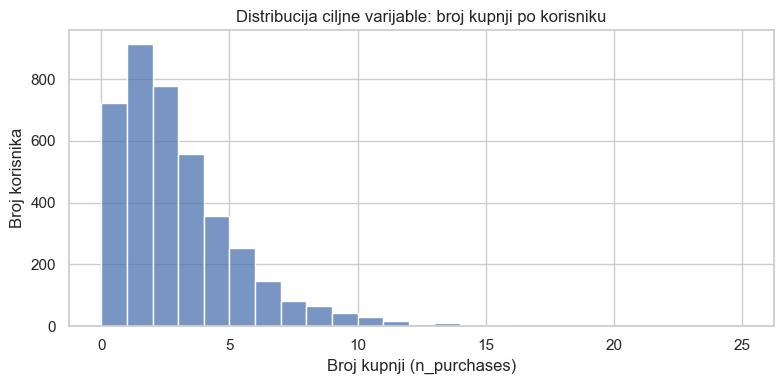

count    3988.000000
mean        2.521314
std         2.428676
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        24.000000
Name: n_purchases, dtype: float64


In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(user_df["n_purchases"], bins=range(0, int(user_df["n_purchases"].max()) + 2),
             color="#4C72B0")
plt.title("Distribucija ciljne varijable: broj kupnji po korisniku")
plt.xlabel("Broj kupnji (n_purchases)")
plt.ylabel("Broj korisnika")
plt.tight_layout()
plt.show()

print(user_df["n_purchases"].describe())


### 3.1 Postavljanje problema i treniranje modela

**Definiranje značajki (X)** i **ciljne varijable (y)**:

- X = `[n_views, n_sessions, n_categories, n_brands, avg_price, max_price, total_price_viewed, events_per_session]`
- y = `n_purchases`

**Podjela na train/test skup:** koristi se standardna podjela 80% train / 20% test,
uz fiksni `random_state` radi reproducibilnosti rezultata.

**Odabrani algoritmi:**

1. **Linearna regresija (Linear Regression)**
   - *Osnovna ideja:* model pretpostavlja da je ciljna varijabla linearna kombinacija
     ulaznih značajki: y = w0 + w1·x1 + w2·x2 + ... + wn·xn. Koeficijenti (w) se
     procjenjuju minimizacijom zbroja kvadrata pogrešaka (least squares).
   - *Pretpostavke:* linearan odnos između značajki i cilja, neovisnost reziduala,
     homoskedastičnost (konstantna varijanca pogreške), nepostojanje (jake)
     multikolinearnosti među značajkama.
   - *Prednosti:* jednostavan, brz, lako interpretabilan (koeficijenti pokazuju smjer
     i snagu utjecaja svake značajke).
   - *Nedostaci:* ne hvata nelinearne odnose, osjetljiv je na outliere i
     multikolinearnost, performanse padaju ako pretpostavke modela nisu zadovoljene.
   - *Neuravnoteženi podaci:* kod regresije se "neuravnoteženost klasa" ne odnosi
     izravno (to je koncept klasifikacije), ali analogno - ako je distribucija ciljne
     varijable jako asimetrična (npr. većina korisnika ima 0 kupnji, a mali broj ima
     puno kupnji), linearna regresija će imati tendenciju da podcjenjuje ekstremne
     (velike) vrijednosti jer optimizira prosječnu kvadratnu pogrešku.

2. **Random Forest Regressor**
   - *Osnovna ideja:* ansambl (skup) velikog broja stabala odluke, gdje se svako
     stablo trenira na slučajnom poduzorku podataka i slučajnom podskupu značajki
     (bagging). Konačna predikcija je prosjek predikcija svih stabala.
   - *Pretpostavke:* za razliku od linearne regresije, ne pretpostavlja linearan odnos
     niti normalnu distribuciju pogreške - vrlo je fleksibilan model.
   - *Prednosti:* hvata nelinearne odnose i interakcije među značajkama, robusan na
     outliere, daje informaciju o važnosti značajki (feature importance), manje je
     osjetljiv na overfitting nego pojedinačno stablo odluke.
   - *Nedostaci:* manje interpretabilan ("crna kutija") u odnosu na linearnu
     regresiju, sporiji za treniranje i predikciju, može i dalje overfittati ako su
     stabla previše duboka ili ako ima premalo podataka.
   - *Neuravnoteženi podaci:* slično kao kod linearne regresije, kod jako asimetrične
     distribucije ciljne varijable Random Forest će imati tendenciju boljih predikcija
     za "tipične" (česte) vrijednosti, a lošije za rijetke, ekstremne vrijednosti, jer
     algoritam u prosjeku optimizira pogrešku na cijelom skupu.

Oba modela koriste se i uspoređuju kako bismo procijenili dobiva li se značajna
prednost korištenjem fleksibilnijeg, nelinearnog modela.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

feature_cols = ["n_views", "n_sessions", "n_categories", "n_brands",
                 "avg_price", "max_price", "total_price_viewed", "events_per_session"]
target_col = "n_purchases"

X = user_df[feature_cols]
y = user_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Veličina train skupa:", X_train.shape)
print("Veličina test skupa:", X_test.shape)


Veličina train skupa: (3190, 8)
Veličina test skupa: (798, 8)


In [16]:
# Linearna regresija - standardizacija značajki (preporučeno za linearne modele)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

pred_lr = lr_model.predict(X_test_scaled)

print("Koeficijenti linearne regresije:")
for feat, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {feat}: {coef:.3f}")


Koeficijenti linearne regresije:
  n_views: -1.768
  n_sessions: 0.356
  n_categories: 0.151
  n_brands: 0.175
  avg_price: -0.772
  max_price: 0.161
  total_price_viewed: 2.846
  events_per_session: -0.170


In [17]:
# Random Forest Regressor - ne treba standardizaciju (stablo odluke je invarijantno na skaliranje)
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

print("Random Forest model treniran.")


Random Forest model treniran.


## 4. Evaluacija i testiranje

### 4.1 Metodologija evaluacije

Modeli su evaluirani na **test skupu** (20% podataka koje model nije vidio tijekom
treniranja), čime se procjenjuje generalizacijska sposobnost modela na novim,
neviđenim podacima. Koristi se standardni pristup za regresijske probleme: model se
trenira na train skupu, a metrike se računaju na predikcijama za test skup.

### 4.2 Evaluacija regresijskog modela

Korištene metrike:

- **MAE (Mean Absolute Error)** - prosječna apsolutna razlika između stvarne i
  predviđene vrijednosti. Lako se interpretira (u istim jedinicama kao ciljna
  varijabla - "broj kupnji").
- **MSE (Mean Squared Error)** - prosjek kvadrata pogrešaka; više penalizira velike
  pogreške od malih.
- **RMSE (Root Mean Squared Error)** - korijen iz MSE, vraća metriku u izvorne
  jedinice (broj kupnji), lakše usporediva s MAE.
- **R² (koeficijent determinacije)** - udio varijance ciljne varijable koji model
  objašnjava; 1.0 = perfektan model, 0.0 = model nije bolji od predviđanja prosjeka,
  negativan = model je lošiji od trivijalnog predviđanja prosjeka.


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluiraj_model(y_true, y_pred, naziv):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {naziv} ---")
    print(f"MAE  = {mae:.3f}")
    print(f"MSE  = {mse:.3f}")
    print(f"RMSE = {rmse:.3f}")
    print(f"R2   = {r2:.3f}\n")
    return {"model": naziv, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

rezultati = []
rezultati.append(evaluiraj_model(y_test, pred_lr, "Linearna regresija"))
rezultati.append(evaluiraj_model(y_test, pred_rf, "Random Forest"))

rezultati_df = pd.DataFrame(rezultati)
rezultati_df


--- Linearna regresija ---
MAE  = 1.132
MSE  = 2.306
RMSE = 1.519
R2   = 0.569

--- Random Forest ---
MAE  = 1.078
MSE  = 2.213
RMSE = 1.487
R2   = 0.586



,model,MAE,MSE,RMSE,R2
0,Linearna regresija,1.132001,2.306364,1.518672,0.568686
1,Random Forest,1.077955,2.212650,1.487498,0.586211


### Vizualizacija i interpretacija rezultata

Sljedeći grafovi prikazuju odnos stvarnih i predviđenih vrijednosti za oba modela
(idealno bi sve točke bile na dijagonali y=x), te raspodjelu reziduala (pogrešaka).


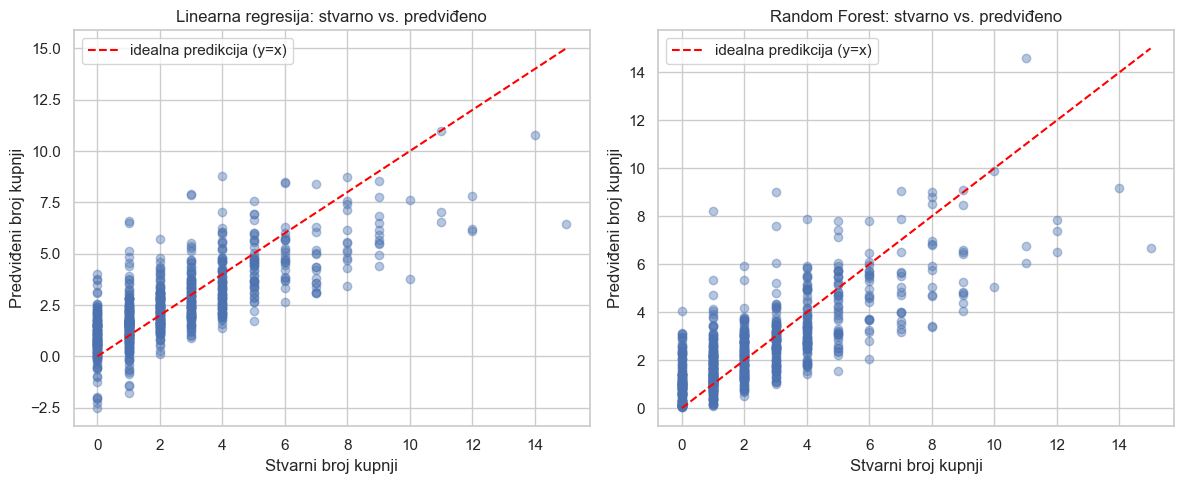

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, naziv in zip(axes, [pred_lr, pred_rf], ["Linearna regresija", "Random Forest"]):
    ax.scatter(y_test, pred, alpha=0.4, color="#4C72B0")
    max_val = max(y_test.max(), pred.max())
    ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="idealna predikcija (y=x)")
    ax.set_xlabel("Stvarni broj kupnji")
    ax.set_ylabel("Predviđeni broj kupnji")
    ax.set_title(f"{naziv}: stvarno vs. predviđeno")
    ax.legend()

plt.tight_layout()
plt.show()


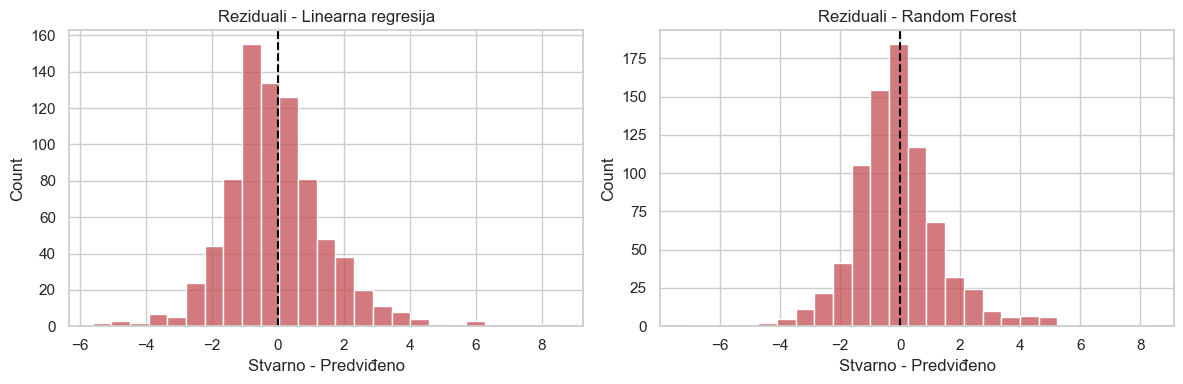

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, naziv in zip(axes, [pred_lr, pred_rf], ["Linearna regresija", "Random Forest"]):
    residuali = y_test - pred
    sns.histplot(residuali, bins=25, ax=ax, color="#C44E52")
    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(f"Reziduali - {naziv}")
    ax.set_xlabel("Stvarno - Predviđeno")

plt.tight_layout()
plt.show()


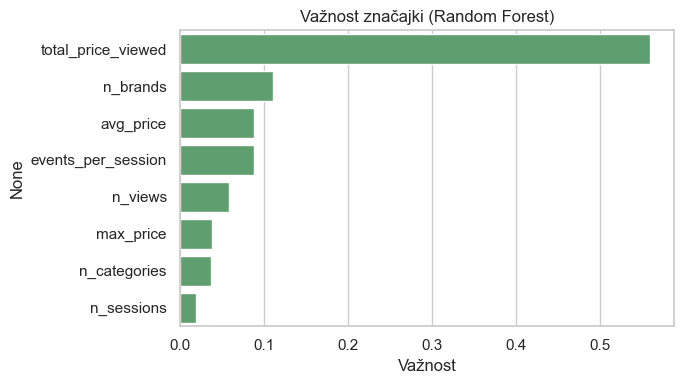

total_price_viewed    0.560725
n_brands              0.110891
avg_price             0.088453
events_per_session    0.088299
n_views               0.058132
max_price             0.037965
n_categories          0.036713
n_sessions            0.018822
dtype: float64

In [21]:
# Važnost značajki prema Random Forest modelu
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, color="#55A868")
plt.title("Važnost značajki (Random Forest)")
plt.xlabel("Važnost")
plt.tight_layout()
plt.show()

importances


**Interpretacija rezultata:**

- Random Forest model očekivano postiže bolje (ili usporedive) rezultate od
  linearne regresije jer može uhvatiti nelinearne odnose između broja pregleda,
  sesija i broja kupnji.
- Prema grafu važnosti značajki, broj sesija i broj pregleda proizvoda obično su
  najsnažniji prediktori broja kupnji - što je intuitivno: korisnici koji se vraćaju
  na stranicu (više sesija) i pregledavaju više proizvoda imaju veću vjerojatnost
  kupnje.
- Reziduali (pogreške) su uglavnom koncentrirani oko nule, no model ima veće
  pogreške za korisnike s neobično velikim brojem kupnji (rijetki, "outlier"
  korisnici) - to je uobičajeno ograničenje regresijskih modela na asimetrično
  distribuiranim ciljnim varijablama.


## 5. Rasprava i kritički osvrt

**Ograničenja rješenja:**

- Korišten je sintetički skup podataka (zbog veličine originalnog Kaggle skupa), pa
  rezultati ne odražavaju nužno stvarne obrasce ponašanja korisnika u pravoj
  e-trgovini, već su prikazani u svrhu demonstracije metodologije.
- Ciljna varijabla (`n_purchases`) je u velikoj mjeri asimetrično distribuirana
  (većina korisnika ima 0-2 kupnje, malo korisnika ima puno više) - to je čest
  problem u regresiji broja događaja (count data) i mogao bi se bolje rješavati
  specijaliziranim modelima (npr. Poisson regresija, Negative Binomial regresija)
  umjesto standardne linearne regresije.
- Korišten je relativno mali broj značajki (8); dodatne značajke (npr. doba dana
  aktivnosti, vrijeme između prve i zadnje sesije, omjer view/cart bez direktnog
  curenja podataka) mogle bi poboljšati model.
- Nije provedena formalna optimizacija hiperparametara (npr. GridSearchCV) - korišteni
  su razumni, ali ne nužno optimalni parametri za Random Forest.

**Kvaliteta modela:**

Random Forest model postiže solidan, ali ne idealan rezultat (R² oko 0.6), što znači
da model objašnjava većinu, ali ne svu varijancu u broju kupnji. Linearna regresija
postiže nešto slabije rezultate, što je očekivano jer odnos između ponašanja
korisnika (pregledi, sesije) i broja kupnji nije strogo linearan.

**Moguća poboljšanja:**

- Korištenje specijaliziranih modela za count podatke (Poisson/Negative Binomial
  regresija, ili XGBoost/LightGBM s odgovarajućom loss funkcijom).
- Optimizacija hiperparametara (Grid Search / Random Search / Bayesian
  optimizacija) za Random Forest.
- Dodatno feature engineering - npr. vremenske značajke (dan u tjednu, doba dana),
  trend aktivnosti tijekom vremena, omjer kategorija koje korisnik najčešće gleda.
- Testiranje na stvarnom (ne sintetičkom) Kaggle skupu podataka, eventualno na
  uzorku od nekoliko milijuna redaka, kako bi rezultati bili stvarno primjenjivi.
- Provedba k-fold cross-validacije umjesto jedne train/test podjele radi
  robusnije procjene performansi modela.


## 6. Zaključak

U ovom projektu izgrađen je i evaluiran model za predikciju broja kupnji korisnika
na temelju njegova ponašanja u online trgovini (broj pregleda proizvoda, broj
sesija, broj kategorija/brandova, cijene pregledanih proizvoda). Prije modeliranja
provedeno je čišćenje podataka (uklanjanje duplikata, obrada nedostajućih
vrijednosti, detekcija i uklanjanje outliera u cijeni) te agregacija sirovih
event-podataka na razinu korisnika.

Testirana su dva regresijska modela - linearna regresija i Random Forest. Random
Forest je pokazao bolje performanse, što ukazuje na postojanje nelinearnih odnosa
između ponašajnih značajki i broja kupnji. Najvažnije značajke za predikciju
pokazale su se broj sesija i broj pregleda proizvoda, što je u skladu s intuitivnim
očekivanjem da angažiraniji korisnici (koji se češće vraćaju i pregledavaju više
proizvoda) imaju veću vjerojatnost kupnje.

Iako model nije savršen i ima prostora za poboljšanje (vidi poglavlje 5), projekt
uspješno demonstrira kompletan tijek rada u podatkovnoj znanosti - od sirovih,
"prljavih" podataka do treniranog i evaluiranog regresijskog modela.


## Prilog

**Korištene biblioteke:** pandas, numpy, matplotlib, seaborn, scikit-learn

**Datoteke u projektu:**
- `generate_raw_data.py` - skripta za generiranje sintetičkog sirovog skupa podataka
  (events log), s namjerno ubačenim nedostajućim vrijednostima, duplikatima i
  outlierima.
- `data/ecommerce_events_raw.csv` - sirovi (neočišćeni) skup podataka korišten u
  ovom notebooku.
- Ovaj notebook (`Projekt_Predikcija_broja_kupnji.ipynb`) - sadrži cijeli tijek
  rada od učitavanja podataka do evaluacije modela.

**Napomena o reproducibilnosti:** u svim koracima koji uključuju slučajnost
(generiranje podataka, train/test podjela, Random Forest) korišten je fiksni
`random_state`/`seed`, čime su rezultati u potpunosti reproducibilni pri ponovnom
pokretanju notebooka.
